# Exp11.0 v4 — frozen-L1 temporal representation control

Aggregation-only notebook for `d0_d1_l1mem2_context_fusion_frozen_l1_v4`.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    p = Path.cwd() if start is None else Path(start)
    for candidate in (p, *p.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('repo root not found')

repo = find_repo_root()
root = repo / 'notebooks' / 'artifacts' / 'experiment_11_0_rsnn_history_internalization' / 'd0_d1_l1mem2_context_fusion_frozen_l1_v4'
runs = pd.read_csv(root / 'run_metrics.csv')
methods = pd.read_csv(root / 'method_summary.csv')
contrasts = pd.read_csv(root / 'paired_contrast_summary.csv')
interactions = pd.read_csv(root / 'interaction_summary.csv')
gaps = pd.read_csv(root / 'temporal_gap_summary.csv')
d0_sources = pd.read_csv(root / 'd0_source_metrics.csv')
runs


,variant,l1_init,topology,fusion,architecture_case,seed,best_epoch,stopped_epoch,native_train_ba,native_val_ba,...,rsnn_comm_window_temporal_gap,readout_pre_valid_fixed250_ba,readout_pre_valid_whole_ba,readout_pre_valid_temporal_gap,readout_comm_valid_fixed250_ba,readout_comm_valid_whole_ba,readout_comm_valid_temporal_gap,readout_comm_window_fixed250_ba,readout_comm_window_whole_ba,readout_comm_window_temporal_gap
0,original,dynamics_only,dense,off,B,11,99,100,0.756223,0.477699,...,0.038504,0.482175,0.416584,0.065590,0.506416,0.457723,0.048693,0.395530,0.357026,0.038504
1,original,dynamics_only,dense,off,B,23,68,98,0.675485,0.484794,...,0.088212,0.493808,0.371860,0.121947,0.509592,0.394496,0.115096,0.467016,0.378805,0.088212
2,original,dynamics_only,dense,off,B,37,71,100,0.678258,0.438848,...,0.079261,0.528080,0.395687,0.132394,0.518676,0.461755,0.056921,0.441801,0.362540,0.079261
3,original,dynamics_only,dense,on,D,11,80,100,0.818818,0.505586,...,0.170227,0.516765,0.351217,0.165548,0.523957,0.464377,0.059581,0.457712,0.391793,0.065919
4,original,dynamics_only,dense,on,D,23,68,98,0.760482,0.528982,...,0.192981,0.573646,0.429580,0.144067,0.582382,0.519654,0.062728,0.542986,0.464850,0.078135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,postencode_mask,pretrained_trainable,ff,off,A,23,81,100,0.935089,0.602733,...,0.063165,0.606053,0.517863,0.088190,0.693683,0.617589,0.076094,0.673731,0.610566,0.063165
104,postencode_mask,pretrained_trainable,ff,off,A,37,89,100,0.942455,0.606699,...,0.062582,0.624960,0.515441,0.109518,0.700421,0.633860,0.066561,0.687148,0.624567,0.062582
105,postencode_mask,pretrained_trainable,ff,on,C,11,50,80,0.965210,0.576802,...,0.142103,0.588449,0.568699,0.019751,0.614196,0.583890,0.030305,0.635084,0.595810,0.039274
106,postencode_mask,pretrained_trainable,ff,on,C,23,31,61,0.878864,0.585435,...,0.102246,0.561893,0.524199,0.037694,0.602924,0.566122,0.036802,0.638819,0.583844,0.054974


## L1 representation preservation
Frozen L1 should have zero relative drift and cosine similarity 1. Trainable pretrained L1 quantifies WCCE-driven representation change.


In [2]:
drift_cols = ['variant','l1_init','architecture_case','topology','fusion','seed','l1_relative_frobenius_drift','l1_cosine_similarity_to_source','l1_pre_valid_fixed250_ba','l1_pre_valid_whole_ba','l1_comm_valid_fixed250_ba','l1_comm_valid_whole_ba','native_test_ba']
runs[drift_cols].sort_values(['variant','l1_init','architecture_case','topology','fusion','seed'])


,variant,l1_init,architecture_case,topology,fusion,seed,l1_relative_frobenius_drift,l1_cosine_similarity_to_source,l1_pre_valid_fixed250_ba,l1_pre_valid_whole_ba,l1_comm_valid_fixed250_ba,l1_comm_valid_whole_ba,native_test_ba
12,original,dynamics_only,A,ff,off,11,NaN,NaN,0.678362,0.486407,0.660454,0.502163,0.503605
13,original,dynamics_only,A,ff,off,23,NaN,NaN,0.691639,0.528624,0.629436,0.541215,0.504818
14,original,dynamics_only,A,ff,off,37,NaN,NaN,0.722250,0.560260,0.676994,0.486277,0.485997
0,original,dynamics_only,B,dense,off,11,NaN,NaN,0.690945,0.478074,0.584492,0.444977,0.419392
1,original,dynamics_only,B,dense,off,23,NaN,NaN,0.689168,0.489649,0.628031,0.468445,0.369482
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,postencode_mask,pretrained_trainable,D,dense,on,23,0.294094,0.970743,0.734591,0.514835,0.676584,0.575561,0.474260
95,postencode_mask,pretrained_trainable,D,dense,on,37,0.244744,0.978528,0.723376,0.471495,0.707271,0.498987,0.413810
99,postencode_mask,pretrained_trainable,D,diagonal,on,11,0.144957,0.991427,0.732507,0.489495,0.650909,0.516414,0.523298
100,postencode_mask,pretrained_trainable,D,diagonal,on,23,0.202961,0.984219,0.722972,0.516507,0.688826,0.571436,0.531359


## Trainable vs frozen pretrained L1
This is the direct estimate of how much final performance depends on allowing WCCE to reshape L1.


In [3]:
trainable_minus_frozen = contrasts[contrasts['contrast'] == 'pretrained_trainable_minus_frozen'].copy()
trainable_minus_frozen


,contrast,variant,l1_init,topology,fusion,delta_native_test_ba_count,delta_native_test_ba_mean,delta_native_test_ba_std,delta_window_test_ba_count,delta_window_test_ba_mean,...,delta_readout_pre_valid_fixed250_ba_std,delta_readout_pre_valid_whole_ba_count,delta_readout_pre_valid_whole_ba_mean,delta_readout_pre_valid_whole_ba_std,delta_readout_pre_valid_temporal_gap_count,delta_readout_pre_valid_temporal_gap_mean,delta_readout_pre_valid_temporal_gap_std,delta_recurrent_to_external_abs_ratio_count,delta_recurrent_to_external_abs_ratio_mean,delta_recurrent_to_external_abs_ratio_std
2,pretrained_trainable_minus_frozen,original,pretrained_trainable_vs_pretrained_frozen,ff,off,3,0.034714,0.018056,3,0.007622,...,0.025506,3,0.056491,0.018054,3,-0.049893,0.042907,3,0.000000,0.000000
5,pretrained_trainable_minus_frozen,original,pretrained_trainable_vs_pretrained_frozen,diagonal,off,3,0.030267,0.003547,3,0.003148,...,0.020527,3,0.029348,0.024344,3,-0.006462,0.043742,3,-0.024773,0.066253
8,pretrained_trainable_minus_frozen,original,pretrained_trainable_vs_pretrained_frozen,dense,off,3,0.058835,0.046327,3,-0.020276,...,0.028086,3,0.037021,0.021501,3,-0.041891,0.022583,3,-0.368972,0.022663
20,pretrained_trainable_minus_frozen,original,pretrained_trainable_vs_pretrained_frozen,ff,on,3,0.031529,0.034278,3,-0.000271,...,0.028356,3,0.042176,0.020923,3,-0.028410,0.046334,3,0.000000,0.000000
23,pretrained_trainable_minus_frozen,original,pretrained_trainable_vs_pretrained_frozen,diagonal,on,3,0.051981,0.012857,3,0.033113,...,0.037143,3,0.034853,0.012863,3,-0.017440,0.033268,3,-0.012671,0.010544
26,pretrained_trainable_minus_frozen,original,pretrained_trainable_vs_pretrained_frozen,dense,on,3,0.057488,0.031744,3,-0.009113,...,0.023773,3,0.036236,0.012859,3,-0.012585,0.012426,3,-0.243531,0.143705
47,pretrained_trainable_minus_frozen,postencode_mask,pretrained_trainable_vs_pretrained_frozen,ff,off,3,0.012336,0.031480,3,0.016920,...,0.024152,3,0.020973,0.036688,3,-0.011660,0.018519,3,0.000000,0.000000
50,pretrained_trainable_minus_frozen,postencode_mask,pretrained_trainable_vs_pretrained_frozen,diagonal,off,3,0.040807,0.036910,3,0.025871,...,0.034533,3,0.025198,0.036721,3,-0.000974,0.030078,3,-0.022464,0.059498
53,pretrained_trainable_minus_frozen,postencode_mask,pretrained_trainable_vs_pretrained_frozen,dense,off,3,0.053460,0.047048,3,-0.004408,...,0.027240,3,0.040834,0.065372,3,0.011042,0.088985,3,-0.384464,0.151991
65,pretrained_trainable_minus_frozen,postencode_mask,pretrained_trainable_vs_pretrained_frozen,ff,on,3,0.012131,0.034923,3,-0.004245,...,0.042905,3,0.026419,0.038514,3,-0.032050,0.036642,3,0.000000,0.000000


## Fusion effect
C-A and D-B are summarized by `fusion_on_minus_off` within each L1 mode, including `pretrained_frozen`.


In [4]:
fusion_on_minus_off = contrasts[contrasts['contrast'] == 'fusion_on_minus_off'].copy()
fusion_on_minus_off


,contrast,variant,l1_init,topology,fusion,delta_native_test_ba_count,delta_native_test_ba_mean,delta_native_test_ba_std,delta_window_test_ba_count,delta_window_test_ba_mean,...,delta_readout_pre_valid_fixed250_ba_std,delta_readout_pre_valid_whole_ba_count,delta_readout_pre_valid_whole_ba_mean,delta_readout_pre_valid_whole_ba_std,delta_readout_pre_valid_temporal_gap_count,delta_readout_pre_valid_temporal_gap_mean,delta_readout_pre_valid_temporal_gap_std,delta_recurrent_to_external_abs_ratio_count,delta_recurrent_to_external_abs_ratio_mean,delta_recurrent_to_external_abs_ratio_std
36,fusion_on_minus_off,original,dynamics_only,ff,on_vs_off,3,-0.012101,0.042636,3,-0.034773,...,0.018220,3,0.046016,0.013355,3,-0.086688,0.023295,3,0.000000,0.000000
37,fusion_on_minus_off,original,dynamics_only,diagonal,on_vs_off,3,-0.035803,0.007369,3,-0.070507,...,0.017584,3,-0.019912,0.008661,3,-0.035241,0.011908,3,-0.415172,0.043789
38,fusion_on_minus_off,original,dynamics_only,dense,on_vs_off,3,0.034857,0.053753,3,-0.047609,...,0.031316,3,0.001512,0.062233,3,0.043201,0.049691,3,0.900046,0.256559
39,fusion_on_minus_off,original,pretrained_trainable,ff,on_vs_off,3,0.016160,0.030546,3,-0.020060,...,0.034045,3,0.045595,0.036693,3,-0.078209,0.002650,3,0.000000,0.000000
40,fusion_on_minus_off,original,pretrained_trainable,diagonal,on_vs_off,3,0.024060,0.030503,3,-0.044164,...,0.055165,3,-0.000037,0.036811,3,-0.064330,0.032867,3,-0.348483,0.016487
41,fusion_on_minus_off,original,pretrained_trainable,dense,on_vs_off,3,0.033243,0.023168,3,-0.061933,...,0.049531,3,0.013876,0.045252,3,0.029089,0.031363,3,0.917958,0.256957
42,fusion_on_minus_off,original,pretrained_frozen,ff,on_vs_off,3,0.019345,0.018016,3,-0.012167,...,0.023943,3,0.059910,0.066851,3,-0.099692,0.089563,3,0.000000,0.000000
43,fusion_on_minus_off,original,pretrained_frozen,diagonal,on_vs_off,3,0.002346,0.041328,3,-0.074129,...,0.032468,3,-0.005542,0.025378,3,-0.053352,0.022046,3,-0.360585,0.056916
44,fusion_on_minus_off,original,pretrained_frozen,dense,on_vs_off,3,0.034591,0.021141,3,-0.073096,...,0.043315,3,0.014661,0.044347,3,-0.000217,0.018173,3,0.792517,0.113882
81,fusion_on_minus_off,postencode_mask,dynamics_only,ff,on_vs_off,3,-0.005910,0.019624,3,0.001582,...,0.014195,3,-0.002454,0.012181,3,-0.047953,0.003250,3,0.000000,0.000000


## A/B/C/D native performance by L1 mode


In [5]:
cols = ['variant','l1_init','architecture_case','topology','fusion','seed','native_test_ba','readout_comm_valid_whole_ba','readout_comm_valid_fixed250_ba','readout_comm_valid_temporal_gap']
runs[cols].sort_values(['variant','l1_init','architecture_case','topology','fusion','seed'])


,variant,l1_init,architecture_case,topology,fusion,seed,native_test_ba,readout_comm_valid_whole_ba,readout_comm_valid_fixed250_ba,readout_comm_valid_temporal_gap
12,original,dynamics_only,A,ff,off,11,0.503605,0.560850,0.630696,0.069846
13,original,dynamics_only,A,ff,off,23,0.504818,0.543711,0.638022,0.094311
14,original,dynamics_only,A,ff,off,37,0.485997,0.527705,0.651672,0.123967
0,original,dynamics_only,B,dense,off,11,0.419392,0.457723,0.506416,0.048693
1,original,dynamics_only,B,dense,off,23,0.369482,0.394496,0.509592,0.115096
...,...,...,...,...,...,...,...,...,...,...
94,postencode_mask,pretrained_trainable,D,dense,on,23,0.474260,0.503873,0.508197,0.004324
95,postencode_mask,pretrained_trainable,D,dense,on,37,0.413810,0.528724,0.569325,0.040601
99,postencode_mask,pretrained_trainable,D,diagonal,on,11,0.523298,0.557490,0.600494,0.043003
100,postencode_mask,pretrained_trainable,D,diagonal,on,23,0.531359,0.605719,0.585951,-0.019768


## Frozen-L1 recurrence effect
B-A and D-C under `pretrained_frozen` test whether recurrence can exploit the original L1 representation without changing it.


In [6]:
frozen_recurrence = contrasts[(contrasts['l1_init'] == 'pretrained_frozen') & contrasts['contrast'].isin(['diagonal_minus_ff','dense_minus_ff'])].copy()
frozen_recurrence


,contrast,variant,l1_init,topology,fusion,delta_native_test_ba_count,delta_native_test_ba_mean,delta_native_test_ba_std,delta_window_test_ba_count,delta_window_test_ba_mean,...,delta_readout_pre_valid_fixed250_ba_std,delta_readout_pre_valid_whole_ba_count,delta_readout_pre_valid_whole_ba_mean,delta_readout_pre_valid_whole_ba_std,delta_readout_pre_valid_temporal_gap_count,delta_readout_pre_valid_temporal_gap_mean,delta_readout_pre_valid_temporal_gap_std,delta_recurrent_to_external_abs_ratio_count,delta_recurrent_to_external_abs_ratio_mean,delta_recurrent_to_external_abs_ratio_std
15,diagonal_minus_ff,original,pretrained_frozen,diagonal_vs_ff,off,3,-0.055477,0.012534,3,-0.148962,...,0.023207,3,0.028360,0.054694,3,-0.037373,0.075264,3,0.523141,0.051281
16,dense_minus_ff,original,pretrained_frozen,dense_vs_ff,off,3,-0.146463,0.034844,3,-0.175196,...,0.008106,3,-0.033223,0.078829,3,-0.085340,0.071904,3,1.831623,0.023793
33,diagonal_minus_ff,original,pretrained_frozen,diagonal_vs_ff,on,3,-0.072476,0.050386,3,-0.210924,...,0.021260,3,-0.037092,0.033302,3,0.008967,0.044497,3,0.162556,0.009950
34,dense_minus_ff,original,pretrained_frozen,dense_vs_ff,on,3,-0.131217,0.028835,3,-0.236125,...,0.023329,3,-0.078472,0.050286,3,0.014135,0.057829,3,2.624140,0.135458
60,diagonal_minus_ff,postencode_mask,pretrained_frozen,diagonal_vs_ff,off,3,-0.028638,0.007608,3,-0.174687,...,0.017054,3,0.017057,0.007241,3,0.003450,0.022012,3,0.535400,0.078549
61,dense_minus_ff,postencode_mask,pretrained_frozen,dense_vs_ff,off,3,-0.208270,0.012625,3,-0.256047,...,0.019273,3,-0.122498,0.040942,3,-0.034087,0.054457,3,2.140996,0.092882
78,diagonal_minus_ff,postencode_mask,pretrained_frozen,diagonal_vs_ff,on,3,-0.014787,0.033907,3,-0.232287,...,0.025738,3,0.017890,0.047901,3,-0.008808,0.034988,3,0.153956,0.010170
79,dense_minus_ff,postencode_mask,pretrained_frozen,dense_vs_ff,on,3,-0.145333,0.052356,3,-0.261929,...,0.078707,3,-0.124965,0.014503,3,-0.006590,0.064561,3,2.684735,0.226273


## Recurrence × Fusion interaction


In [7]:
recurrence_x_fusion = interactions[interactions['interaction'] == 'recurrence_x_fusion'].copy()
recurrence_x_fusion


,interaction,variant,l1_init,topology,fusion,interaction_native_test_ba_count,interaction_native_test_ba_mean,interaction_native_test_ba_std,interaction_window_test_ba_count,interaction_window_test_ba_mean,...,interaction_readout_pre_valid_fixed250_ba_std,interaction_readout_pre_valid_whole_ba_count,interaction_readout_pre_valid_whole_ba_mean,interaction_readout_pre_valid_whole_ba_std,interaction_readout_pre_valid_temporal_gap_count,interaction_readout_pre_valid_temporal_gap_mean,interaction_readout_pre_valid_temporal_gap_std,interaction_recurrent_to_external_abs_ratio_count,interaction_recurrent_to_external_abs_ratio_mean,interaction_recurrent_to_external_abs_ratio_std
0,recurrence_x_fusion,original,dynamics_only,diagonal,on_vs_off,3,-0.023702,0.048648,3,-0.035734,...,0.034432,3,-0.065928,0.014703,3,0.051447,0.025629,3,-0.415172,0.043789
1,recurrence_x_fusion,original,dynamics_only,dense,on_vs_off,3,0.046958,0.030854,3,-0.012836,...,0.028062,3,-0.044505,0.074226,3,0.129889,0.047161,3,0.900046,0.256559
2,recurrence_x_fusion,original,pretrained_trainable,diagonal,on_vs_off,3,0.007900,0.053353,3,-0.024104,...,0.068935,3,-0.045632,0.038595,3,0.013879,0.030863,3,-0.348483,0.016487
3,recurrence_x_fusion,original,pretrained_trainable,dense,on_vs_off,3,0.017083,0.029748,3,-0.041873,...,0.083573,3,-0.031719,0.077244,3,0.107298,0.030313,3,0.917958,0.256957
4,recurrence_x_fusion,original,pretrained_frozen,diagonal,on_vs_off,3,-0.016999,0.040803,3,-0.061962,...,0.043592,3,-0.065452,0.075926,3,0.046341,0.111169,3,-0.360585,0.056916
5,recurrence_x_fusion,original,pretrained_frozen,dense,on_vs_off,3,0.015246,0.038216,3,-0.060929,...,0.031420,3,-0.045249,0.111198,3,0.099475,0.097443,3,0.792517,0.113882
10,recurrence_x_fusion,postencode_mask,dynamics_only,diagonal,on_vs_off,3,0.004864,0.034397,3,-0.134167,...,0.051414,3,-0.041997,0.048628,3,0.031812,0.009557,3,-0.382452,0.061559
11,recurrence_x_fusion,postencode_mask,dynamics_only,dense,on_vs_off,3,0.093557,0.037802,3,-0.052265,...,0.084900,3,0.052638,0.020816,3,0.024516,0.075741,3,0.574205,0.308736
12,recurrence_x_fusion,postencode_mask,pretrained_trainable,diagonal,on_vs_off,3,-0.018726,0.007250,3,-0.054018,...,0.037580,3,-0.043079,0.038942,3,0.014374,0.037713,3,-0.367890,0.039617
13,recurrence_x_fusion,postencode_mask,pretrained_trainable,dense,on_vs_off,3,0.094092,0.085387,3,0.034940,...,0.043337,3,0.046719,0.012241,3,0.038601,0.033905,3,0.658720,0.401996


## Paired D1-D0 effect


In [8]:
d1_minus_d0 = contrasts[contrasts['contrast'] == 'd1_minus_d0'].copy()
d1_minus_d0


,contrast,variant,l1_init,topology,fusion,delta_native_test_ba_count,delta_native_test_ba_mean,delta_native_test_ba_std,delta_window_test_ba_count,delta_window_test_ba_mean,...,delta_readout_pre_valid_fixed250_ba_std,delta_readout_pre_valid_whole_ba_count,delta_readout_pre_valid_whole_ba_mean,delta_readout_pre_valid_whole_ba_std,delta_readout_pre_valid_temporal_gap_count,delta_readout_pre_valid_temporal_gap_mean,delta_readout_pre_valid_temporal_gap_std,delta_recurrent_to_external_abs_ratio_count,delta_recurrent_to_external_abs_ratio_mean,delta_recurrent_to_external_abs_ratio_std
90,d1_minus_d0,d1_vs_d0,dynamics_only,ff,off,3,0.061662,0.031320,3,0.082605,...,0.043222,3,0.103433,0.035963,3,-0.071751,0.038552,3,0.000000,0.000000
91,d1_minus_d0,d1_vs_d0,dynamics_only,ff,on,3,0.067853,0.038360,3,0.118959,...,0.053412,3,0.054962,0.053059,3,-0.033017,0.015398,3,0.000000,0.000000
92,d1_minus_d0,d1_vs_d0,dynamics_only,diagonal,off,3,0.060949,0.012616,3,0.048180,...,0.008888,3,0.094513,0.027571,3,-0.035415,0.030823,3,-0.017263,0.030862
93,d1_minus_d0,d1_vs_d0,dynamics_only,diagonal,on,3,0.095707,0.003583,3,-0.013898,...,0.057639,3,0.069974,0.019386,3,-0.016315,0.038433,3,0.015456,0.005839
94,d1_minus_d0,d1_vs_d0,dynamics_only,dense,off,3,-0.002016,0.029742,3,0.035974,...,0.040560,3,0.019008,0.020472,3,-0.017065,0.024416,3,0.474237,0.283665
95,d1_minus_d0,d1_vs_d0,dynamics_only,dense,on,3,0.050774,0.041217,3,0.032899,...,0.056390,3,0.067681,0.053670,3,-0.083704,0.004205,3,0.148396,0.190568
96,d1_minus_d0,d1_vs_d0,pretrained_trainable,ff,off,3,0.029445,0.012673,3,0.089917,...,0.017736,3,0.062425,0.009323,3,-0.039498,0.026814,3,0.000000,0.000000
97,d1_minus_d0,d1_vs_d0,pretrained_trainable,ff,on,3,-0.001404,0.068524,3,0.070525,...,0.058615,3,0.040186,0.042222,3,-0.022156,0.017710,3,0.000000,0.000000
98,d1_minus_d0,d1_vs_d0,pretrained_trainable,diagonal,off,3,0.089200,0.005998,3,0.077617,...,0.016039,3,0.082490,0.031870,3,-0.031421,0.019601,3,0.014567,0.032547
99,d1_minus_d0,d1_vs_d0,pretrained_trainable,diagonal,on,3,0.031726,0.026400,3,0.028311,...,0.037436,3,0.062805,0.033948,3,-0.013585,0.051890,3,-0.004839,0.044908


## Temporal internalization
Compare Fixed250-minus-whole from L1 to context/RSNN to final readout, with special attention to pretrained_frozen.


In [9]:
gap_view = gaps[['variant','l1_init','architecture_case','topology','fusion','layer','support','fixed250_ba_mean','whole_ba_mean','temporal_gap_mean']]
gap_view.sort_values(['variant','l1_init','architecture_case','topology','fusion','support','layer'])


,variant,l1_init,architecture_case,topology,fusion,layer,support,fixed250_ba_mean,whole_ba_mean,temporal_gap_mean
24,original,dynamics_only,A,ff,off,l1,valid,0.655628,0.509885,0.145743
28,original,dynamics_only,A,ff,off,readout,valid,0.640130,0.544089,0.096042
26,original,dynamics_only,A,ff,off,rsnn,valid,0.640130,0.544089,0.096042
25,original,dynamics_only,A,ff,off,l1,window,0.654476,0.474522,0.179954
29,original,dynamics_only,A,ff,off,readout,window,0.653944,0.510223,0.143721
...,...,...,...,...,...,...,...,...,...,...
202,postencode_mask,pretrained_trainable,D,diagonal,on,readout,valid,0.611937,0.579472,0.032465
200,postencode_mask,pretrained_trainable,D,diagonal,on,rsnn,valid,0.681601,0.574556,0.107044
199,postencode_mask,pretrained_trainable,D,diagonal,on,l1,window,0.689250,0.528363,0.160887
203,postencode_mask,pretrained_trainable,D,diagonal,on,readout,window,0.578089,0.502370,0.075720


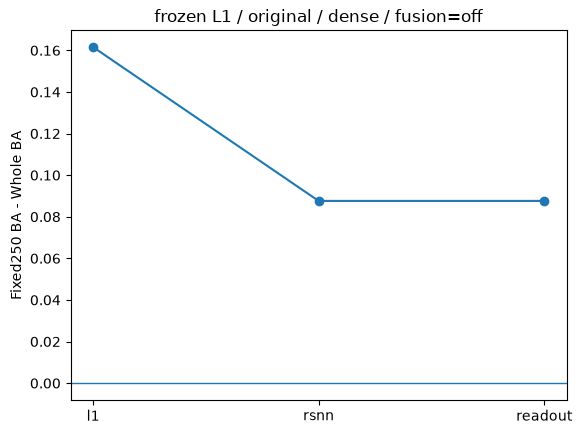

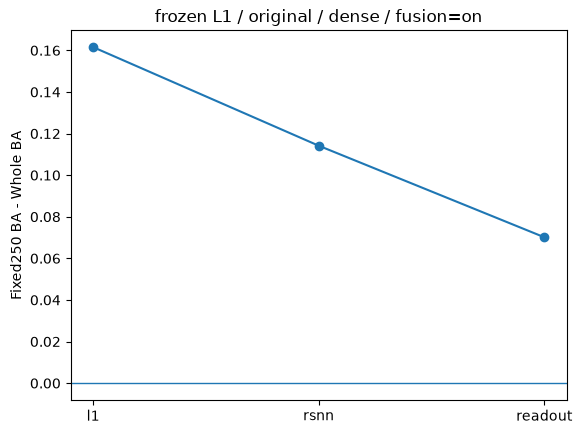

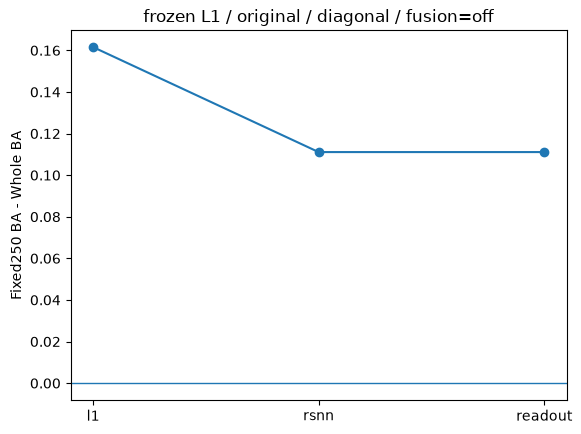

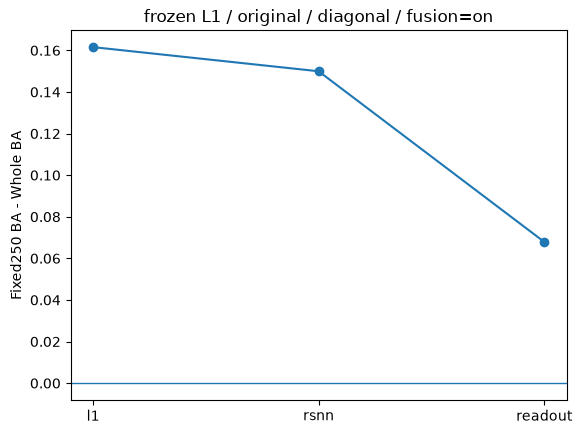

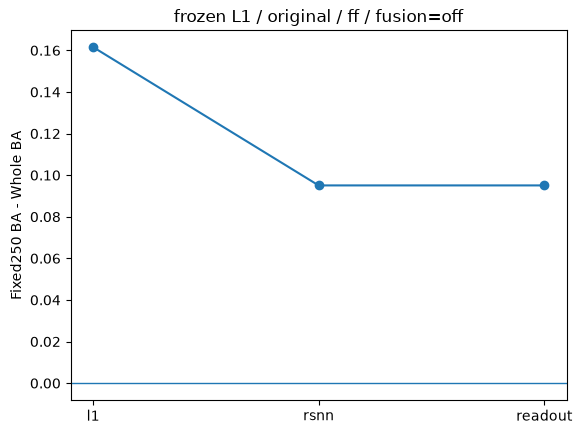

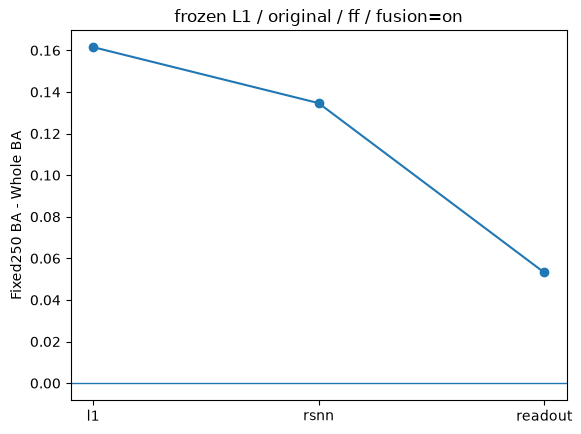

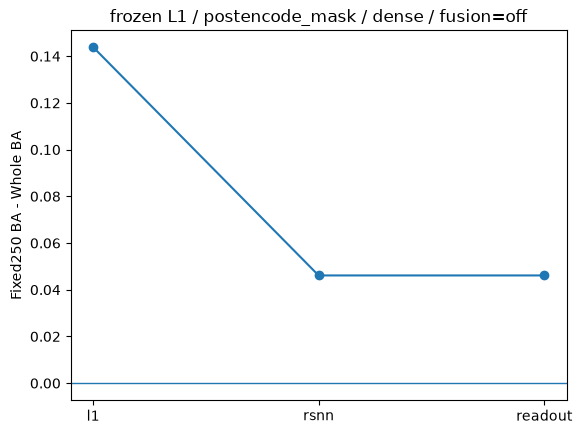

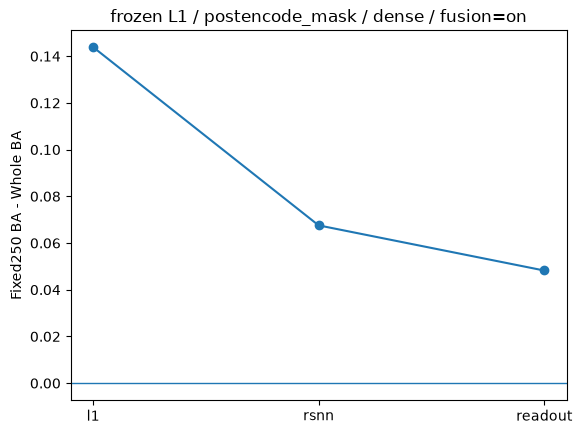

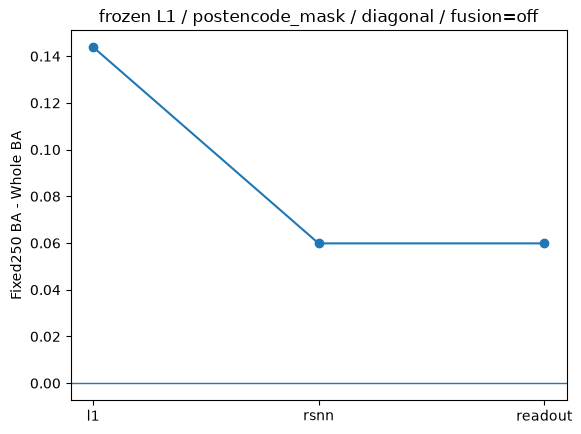

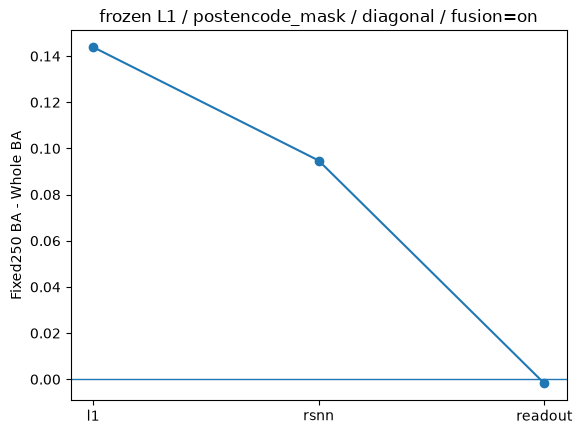

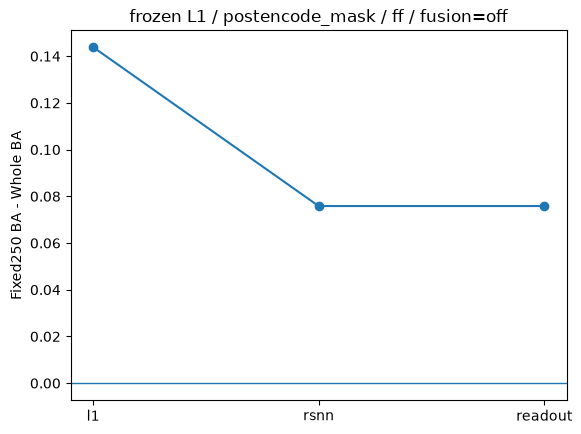

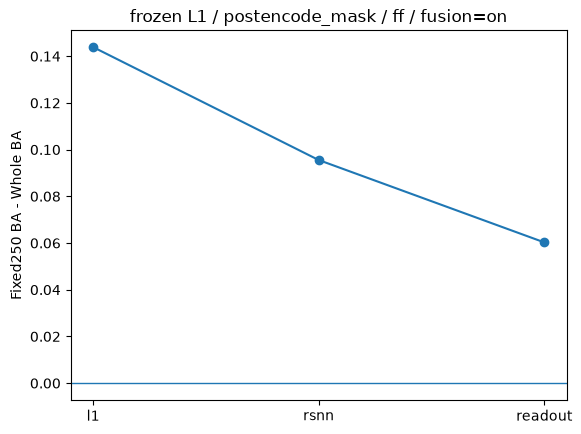

In [10]:
plot_data = gaps[(gaps['support'] == 'valid') & (gaps['l1_init'] == 'pretrained_frozen')].copy()
for (variant, topology, fusion), group in plot_data.groupby(['variant','topology','fusion']):
    ordered = group.set_index('layer').loc[['l1','rsnn','readout']].reset_index()
    plt.figure()
    plt.plot(ordered['layer'], ordered['temporal_gap_mean'], marker='o')
    plt.axhline(0, linewidth=1)
    plt.ylabel('Fixed250 BA - Whole BA')
    plt.title(f'frozen L1 / {variant} / {topology} / fusion={fusion}')
    plt.show()


## D0 matched-source sanity check


In [11]:
d0_sources


,variant,seed,best_epoch,stopped_epoch,train_ba,val_ba,test_ba
0,original,11,97,100,0.972729,0.542232,0.525980
1,original,23,88,100,0.939415,0.576295,0.500375
2,original,37,91,100,0.951849,0.554580,0.449521
